# Detecção de Fraudes  em transações

In [2]:
#utilização de dataset real para testes (creditcard.csv)
import pandas as pd
import numpy as np
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


O objetivo é encontrar padrões que dirão se a transação é fraudulenta ou não


## Problema de classificação desbalanceada

In [3]:
df['Class'].value_counts(normalize=True)

# Isso analisa a proporção do dataest, no nosso caso, esse dataset é desbalanceado
# já que 99% das transações não são fraudes e apenas 0,17% são fraudes,
# isso dificulta o treinamento de modelos já que, se o modelo chutar que
# todas as transações não são uma fraude, sua acurácia estará em 99% já que esse
# é o padrão do dataset, mas, na vida real, isso não ajuda em nada

,proportion
Class,
0,0.998273
1,0.001727


## Feature Engineering

criamos variáveis que ajudam o modelo

In [4]:
df['Amount'] = np.log1p(df['Amount'])
# A função log1p aplica uma normalização logarítimica


In [6]:
# Padronização - ajuste dos dados para uma escala comum
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])


In [8]:
from sklearn.model_selection import train_test_split
X = df.drop('Class',axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

## Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.65      0.74       148

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



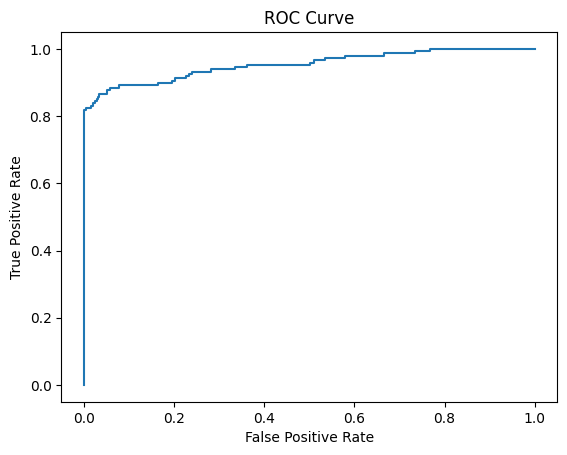

AUC 0.9529971497964933


In [11]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_pred_proba)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('AUC', roc_auc_score(y_test, y_pred_proba))


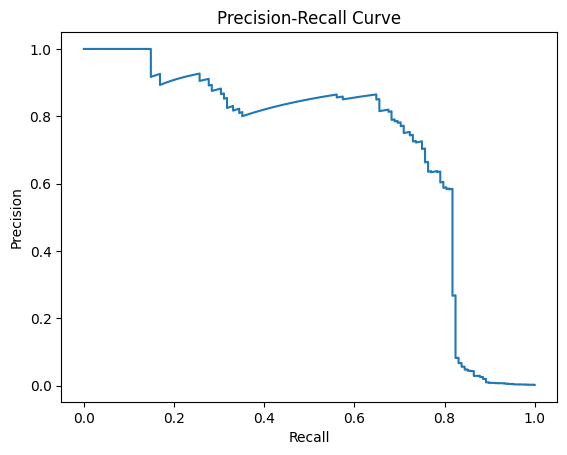

In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

No início da curva, a precisão está alta, isso significa que o modelo só está marcando uma transição como fraude quando tem 100% de certeza disso, o que faz a precisão ficar no máximo, no entanto, ele deixa passar muitas transações que eram fraudulentas mas, como ele não tinha certeza total, ignorou.
Já com o aumento do recall, ele marca mais transações como fraudulentas usando critérios mais brandos, mas isso faz com que ele marque transações que não eram fraudulentas como fraude.
É necessário encontrar o equilíbrio entre eles para obter o resultado mais assertivo.

## Balanceamento de dados


In [13]:
# Undersampling
fraudes = df[df['Class'] == 1]
nao_fraudes = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)

df_undersampled = pd.concat([fraudes, nao_fraudes])

# Separa a classe minoritária (fraudes) e depois seleciona
# a mesma quantidade de registros da classe majoritária (não fraudes)
# e então junta tudo.
# Isso equilibra o dataset mas nos faz perder muitos dados.

In [14]:
# Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Cria exemplos sintéticos da classe minoritária (fraudes)
# Isso equilibra o dataset, mas, pode ser perigoso trabalhar
# com dados irreais

Para escolher entre **Undersampling** e **Oversampling** não há uma regra cravada, é necessário testar e encontrar a melhor opção para o seu cenário

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
n_estimators=50,
max_depth=10,
class_weight='balanced',
random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [19]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)

threshold = 0.3

y_pred_custom = (y_pred_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.69      0.74       148

    accuracy                           1.00     85443
   macro avg       0.90      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



## Modelo Avançado - XGBoost

XGBoost é um dos algoritimos mais usados em competições e meercado.
Ele é mais poderoso que Random Forest para muitos problemas

In [20]:
from xgboost import XGBClassifier

xgh = XGBClassifier(
    scale_pos_weight=10, # Ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric='logloss',
)
xgh.fit(X_train, y_train)
y_pred_xgb = xgh.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:59:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



## Importância das Variáveis

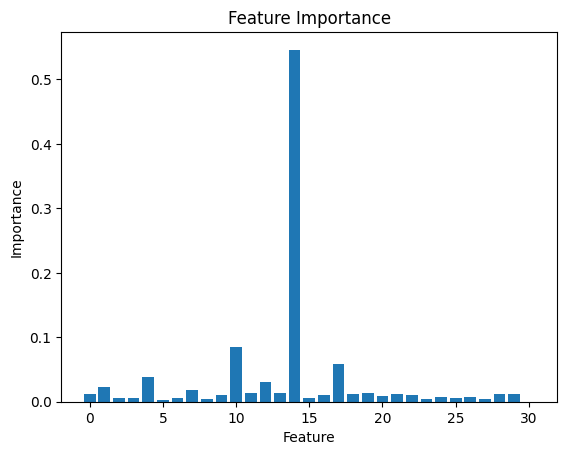

In [23]:
import matplotlib.pyplot as plt

inportanclass = xgh.feature_importances_

plt.bar(range(len(inportanclass)), inportanclass)
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

## Ajuste de Hiperparâmetros


In [27]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100]
}

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    scoring='recall',
    cv=3
)

grid_search.fit(X_train, y_train)

print('Melhor modelo: ', grid_search.best_params_)

Melhor modelo:  {'max_depth': 5, 'n_estimators': 100}


## Explicabilidade (SHAP)

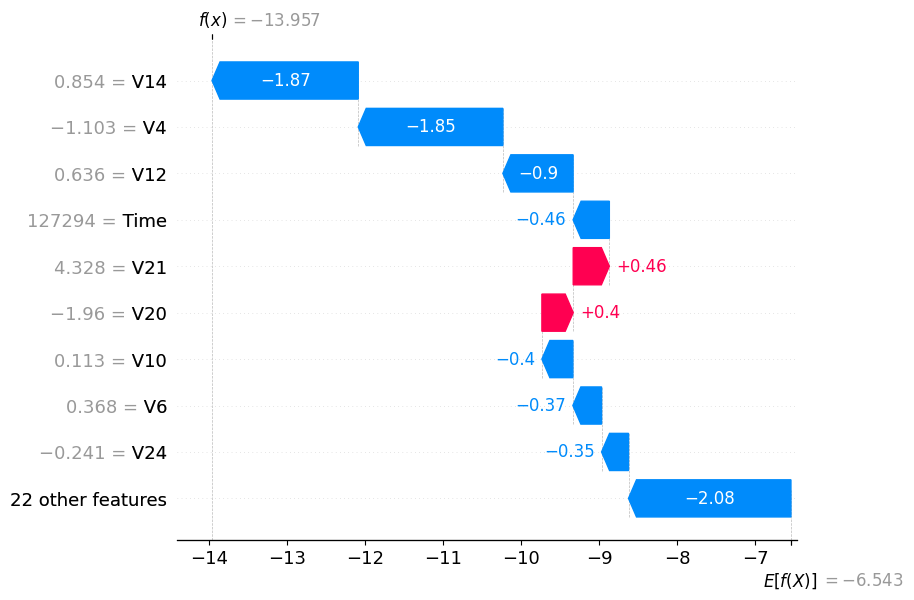

In [31]:
import shap
explainer = shap.Explainer(xgh)
shap_values = explainer(X_test[:100])

shap.plots.waterfall(shap_values[0])